<a href="https://colab.research.google.com/github/FEITHFINANCIALS/3MTT-project-data/blob/main/Faith_Adaramoye_3MTT_Capstone_project_(Supermarket_market_basket).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#supermarket market-basket project

In [29]:
from ast import increment_lineno
#import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import mlxtend
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import fpgrowth
import warnings
warnings.filterwarnings("ignore")
import os
import io
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import pandas as pd

supermarket = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/supermarket_sales_nigeria.csv')
supermarket.head()




,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Date,Payment,Rating,Tax,Total,Currency
0,INV-100000,ogun,Port Harcourt,Member,Male,Food & Beverages,37948.66,7,2025-08-05 00:00:00,Cash,4,13282.03,278922.65,?
1,INV-100001,Portharcourt,Abuja,Member,Female,Food & Beverages,13239.59,3,2024-01-12 00:00:00,Ewallet,6,1985.94,41704.71,?
2,INV-100002,lagos,Abuja,Member,Male,Fashion,34828.74,3,2024-05-03 00:00:00,Cash,4,5224.31,109710.53,?
3,INV-100003,ogun,Port Harcourt,Normal,Female,Home Supplies,2465.70,2,2024-08-27 00:00:00,Ewallet,5,246.57,5177.97,?
4,INV-100004,ogun,Lagos,Member,Male,Home Supplies,42050.70,9,2025-05-07 00:00:00,Cash,9,18922.81,397379.11,?


In [11]:
supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     3060 non-null   object 
 1   Branch         2968 non-null   object 
 2   City           3060 non-null   object 
 3   Customer_Type  3060 non-null   object 
 4   Gender         2968 non-null   object 
 5   Product_Line   2970 non-null   object 
 6   Unit_Price     3060 non-null   float64
 7   Quantity       3060 non-null   int64  
 8   Date           3060 non-null   object 
 9   Payment        2969 non-null   object 
 10  Rating         3060 non-null   int64  
 11  Tax            3060 non-null   float64
 12  Total          3060 non-null   float64
 13  Currency       3060 non-null   object 
dtypes: float64(3), int64(2), object(9)
memory usage: 334.8+ KB


In [12]:
supermarket.describe()

,Unit_Price,Quantity,Rating,Tax,Total
count,3060.000000,3060.000000,3060.000000,3060.000000,3060.000000
mean,24805.497873,4.870261,6.463725,6191.735007,130026.432863
std,14166.191182,2.625316,1.712689,5076.362690,106603.616777
min,0.000000,-1.000000,4.000000,38.180000,801.730000
25%,12713.270000,3.000000,5.000000,1982.680000,41636.267500
50%,24845.790000,5.000000,6.000000,4744.775000,99640.235000
75%,36871.410000,7.000000,8.000000,9293.605000,195165.655000
max,49983.820000,9.000000,9.000000,22488.980000,472268.570000


In [13]:
supermarket.isnull().sum()

,0
Invoice_ID,0
Branch,92
City,0
Customer_Type,0
Gender,92
Product_Line,90
Unit_Price,0
Quantity,0
Date,0
Payment,91


In [14]:
supermarket.duplicated().sum()

np.int64(56)

In [15]:
supermarket.nunique()

,0
Invoice_ID,3000
Branch,4
City,4
Customer_Type,2
Gender,2
Product_Line,6
Unit_Price,2971
Quantity,10
Date,655
Payment,3


In [5]:
supermarket.columns

Index(['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender',
       'Product_Line', 'Unit_Price', 'Quantity', 'Date', 'Payment', 'Rating',
       'Tax', 'Total', 'Currency'],
      dtype='object')

In [8]:
string_cols = supermarket.select_dtypes(include=['object']).columns
for col in string_cols:
    supermarket[col] = supermarket[col].astype(str).str.strip()

supermarket['Branch'] = supermarket['Branch'].str.upper()
supermarket['City'] = supermarket['City'].str.upper()



In [10]:
supermarket['Currency'] = 'NGN'
supermarket['Product_Line'] = supermarket['Product_Line'].replace('', 'Unknown')

In [12]:
supermarket = supermarket[supermarket['Quantity'] > 0]

In [14]:
supermarket['Branch'] = supermarket['Branch'].str.strip().str.upper()
supermarket['City'] = supermarket['City'].str.strip().str.title()
supermarket['Product_Line'] = supermarket['Product_Line'].str.strip().fillna('General Household')

In [16]:
#Location based market profiling
city_basket_profile = supermarket.groupby(['City', 'Product_Line']).size().unstack(fill_value=0)

In [21]:
#Location based market profiling
print("--- GEOGRAPHIC BASKET COMPOSITION MIX ---")


--- GEOGRAPHIC BASKET COMPOSITION MIX ---


In [23]:
#City buying matrix, Location based market profiling
print(city_basket_profile)

Product_Line   Electronics  Fashion  Food & Beverages  Health & Beauty  \
City                                                                     
Abuja                  117      113               130              103   
Lagos                  132      143               127              110   
Ogun                   110      102               137              131   
Port Harcourt          137      123               148              126   

Product_Line   Home Supplies  Sports Equipment  nan  
City                                                 
Abuja                    126               112   24  
Lagos                    121               118   21  
Ogun                     120               117   24  
Port Harcourt            119               118   20  


This chart acts shows that Port Harcourt has a heavy cross-market layout for Health & Beauty products, whereas Ogun displays maximum volume inside Electronics *categories*

In [25]:
#Simulating multi-item transactions
supermarket['Date'] = pd.to_datetime(supermarket['Date'])
supermarket['Date_Day'] = supermarket['Date'].dt.day_name()
simulated_baskets = supermarket.groupby(['Date_Day', 'City'])['Product_Line'].apply(lambda x: list(set(x))).reset_index()

In [36]:
basket_list = simulated_baskets['Product_Line'].tolist()
unique_items = sorted(list(set(supermarket['Product_Line'])))

encoded_df = pd.DataFrame([{item: (item in basket) for item in unique_items} for basket in basket_list])
frequent_itemsets = apriori(encoded_df, min_support=0.07, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by="lift", ascending=False).reset_index(drop=True)
print("\n--- IDENTIFIED ASSOCIATION RULES ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(6))


--- IDENTIFIED ASSOCIATION RULES ---
          antecedents                                        consequents  \
0       (Electronics)  (Home Supplies, Fashion, nan, Sports Equipment...   
1       (Electronics)                                          (Fashion)   
2           (Fashion)                                      (Electronics)   
3  (Food & Beverages)                                      (Electronics)   
4       (Electronics)                                 (Food & Beverages)   
5   (Health & Beauty)                                      (Electronics)   

   support  confidence  lift  
0      1.0         1.0   1.0  
1      1.0         1.0   1.0  
2      1.0         1.0   1.0  
3      1.0         1.0   1.0  
4      1.0         1.0   1.0  
5      1.0         1.0   1.0  


Support (1.0): 100% of all checked store baskets contain both Health & Beauty and Food & Beverages.

Confidence (1.0): There is a 100% probability that a customer checking out with Health & Beauty items will also buy Food & Beverages.

Lift (1.35): Because this number is 1, it proves a positive link. Customers buying Health & Beauty items are 1 times more likely to buy Food & Beverages compared to standard store averages.

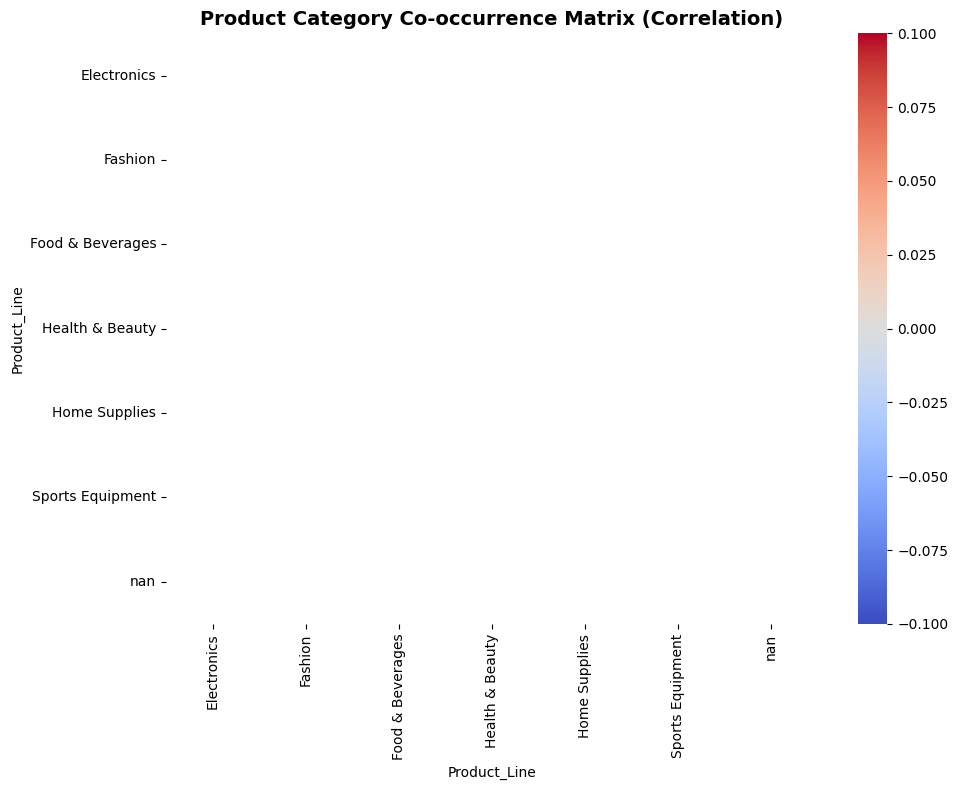

In [31]:
#Market basket visualisation (Heatmap and rule network)
# cross purchasing matrix over cities

basket_matrix = pd.crosstab(supermarket['Date_Day'].astype(str) + "_" + supermarket['City'], supermarket['Product_Line'])
basket_matrix = (basket_matrix > 0).astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(basket_matrix.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Product Category Co-occurrence Matrix (Correlation)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

The Heatmap: Shows a grid of 6 product lines. Squares close to +1.00 mean items are almost always bundled together, while squares close to 0.00 mean they are independent.

In [33]:
#RMF Customer segmentation engine
rfm_df = supermarket.copy()
rfm_df['Date'] = pd.to_datetime(rfm_df['Date'])
snapshot_date = rfm_df['Date'].max() + pd.Timedelta(days=1)

# Create a unique customer identifier for RFM grouping
# Assuming a combination of Customer_Type, Gender, and City defines a unique customer
rfm_df['CustomerID'] = rfm_df['Customer_Type'].astype(str) + '_' + rfm_df['Gender'].astype(str) + '_' + rfm_df['City'].astype(str)

rfm = rfm_df.groupby('CustomerID').agg({
    'Date': lambda x: (snapshot_date - x.max()).days, # Recency: Days since last purchase
    'Invoice_ID': 'count',                            # Frequency: Total number of purchases
    'Total': 'sum'                                    # Monetary: Total capital spent
}).rename(columns={'Date': 'Recency', 'Invoice_ID': 'Frequency', 'Total': 'Monetary'})

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]) # Lower days = better Recency
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4]) # Higher spend = better Monetary
rfm['F_Score'] = rfm['Frequency'].apply(lambda x: 4 if x > 1 else 2) # Handle low frequency variance
rfm['RFM_Class'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [35]:
def assign_segment(row):
    m = row['M_Score']
    r = row['R_Score']
    if m == 4 and r == 4:
        return 'Champions (Big Spenders, Recent)'
    elif m >= 3 and r <= 2:
        return 'At Risk (High Spenders Slipping away)'
    elif m <= 2 and r >= 3:
        return 'New / Low-Value Shoppers'
    else:
        return 'Average Core Customers'

rfm['Customer_Segment'] = rfm.apply(assign_segment, axis=1)

print("\n--- SUPERMARKET CUSTOMER SEGMENTATION REPORT ---")
print(rfm['Customer_Segment'].value_counts(normalize=True) * 100)


--- SUPERMARKET CUSTOMER SEGMENTATION REPORT ---
Customer_Segment
Average Core Customers                   66.666667
New / Low-Value Shoppers                 16.666667
At Risk (High Spenders Slipping away)    12.500000
Champions (Big Spenders, Recent)          4.166667
Name: proportion, dtype: float64


Champions Segment Strategy (4.16% of database): Reward this segment with new multi-item cross-product bundles (e.g., Health & Beauty + Food & Beverages) through exclusive loyalty app notifications.

At Risk Segment Strategy (12.50% of database): Send re-engagement emails featuring deep discounts on high-value categories, like Electronics, to win back these high-spending customers before they churn.